Link to the learning path: https://chatgpt.com/c/69179978-f50c-832e-b7d5-40d801098c98

In [1]:
import numpy as np
def sigmoid(z):
  return 1/(1+np.exp(-z))

In [4]:
class LogisticRegressionGD:
  def __init__(self, learning_rate = 0.01, n_iterations= 1000):
    self.learning_rate = learning_rate
    self.n_iterations = n_iterations
    self.weight = None
    self.bias = None
    self.loss_history = []

  def fit (self, X, y):
    X = np.array(X, dtype  = float)
    y = np.array(y, dtype = float)

    n_samples, n_features = X.shape

    self.weight = np.zeros(n_features)
    self.bias = 0.0

    for _ in range(self.n_iterations):
      linear_model = np.dot(X, self.weight) + self.bias
      # linear_mode = z
      y_pred = sigmoid(linear_model)

      # computer gradients
      dw = (1/n_samples) * np.dot(X.T, (y_pred - y))
      db = (1/n_samples) * np.sum(y_pred - y)

      # update parameters
      self.weight = self.weight - self.learning_rate * dw
      self.bias = self.bias - self.learning_rate * db

      # loss function
      eps = 1e-15
      # to avoid log(0) we clip the y_predict
      y_pred_clipped = np.clip(y_pred, eps, 1-eps)
      loss = -(1/n_samples) * np.sum(y * np.log(y_pred_clipped) + (1-y) * np.log(1-y_pred_clipped))
      self.loss_history.append(loss)

  def predict_proba (self, X):
    X = np.array(X, dtype = float)
    linear_model = np.dot(X, self.weight) + self.bias
    return sigmoid (linear_model)

  def predict (self, X, threshold = 0.5):
    proba = self.predict_proba(X)
    return (proba >= threshold).astype (int)





In [5]:
# Tiny toy data: 2D points, label 0 or 1
X_train = np.array([
    [0.2, 0.1],
    [0.4, 0.2],
    [0.3, 0.4],
    [0.6, 0.9],
    [0.8, 0.7],
    [0.9, 0.6],
])

y_train = np.array([0, 0, 0, 1, 1, 1])  # first 3 are class 0, last 3 are class 1

model = LogisticRegressionGD(learning_rate=0.5, n_iterations=2000)
model.fit(X_train, y_train)

print("weights:", model.weight)
print("bias:", model.bias)

# Predictions on training data
y_pred = model.predict(X_train)
print("Predicted labels:", y_pred)
print("True labels     :", y_train)
print("Training accuracy:", np.mean(y_pred == y_train))


weights: [9.1189543 9.0444624]
bias: -9.465565595996695
Predicted labels: [0 0 0 1 1 1]
True labels     : [0 0 0 1 1 1]
Training accuracy: 1.0


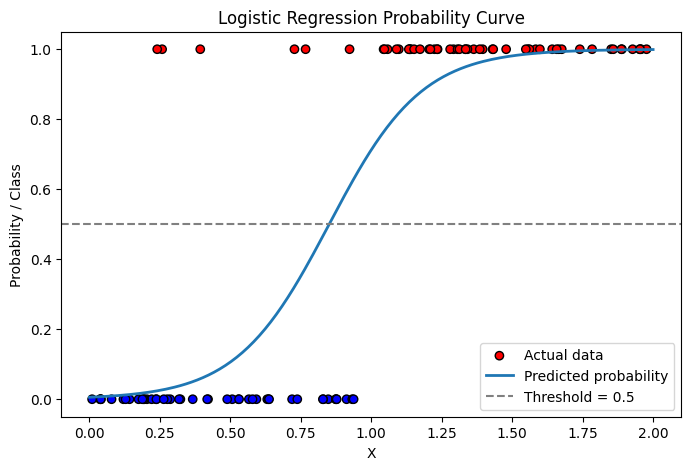

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# --- Generate simple 1D binary data ---
np.random.seed(0)
X = 2 * np.random.rand(100,1)
y = (X[:,0] > 1).astype(int)  # class 1 if x > 1, else class 0
y = y + (np.random.rand(100) > 0.9).astype(int)  # add a little noise
y = (y > 0).astype(int)

# --- Train logistic regression ---
model = LogisticRegressionGD(learning_rate=0.01, n_iterations=200000)
model.fit(X, y)

# --- Make smooth predictions for plotting ---
X_plot = np.linspace(0, 2, 200).reshape(-1,1)
y_proba = model.predict_proba(X_plot)

# --- PLOT ---
plt.figure(figsize=(8,5))

# scatter actual data
plt.scatter(X[:,0], y, c=y, cmap="bwr", edgecolors='k', label="Actual data")

# predicted probability curve
plt.plot(X_plot, y_proba, label="Predicted probability", linewidth=2)

# decision boundary at p = 0.5
plt.axhline(0.5, color='gray', linestyle='--', label="Threshold = 0.5")

plt.xlabel("X")
plt.ylabel("Probability / Class")
plt.title("Logistic Regression Probability Curve")
plt.legend()
plt.show()
